# AP1 — Análise Exploratória do Dataset Ames Housing

**Convenção de nomes:** ao longo do notebook cada variável é apresentada pelo **nome
legível** seguido do **nome original no arquivo entre parênteses** — ex.: *Preço de Venda
(SalePrice)*.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Importação e rastreabilidade

**Identificação e procedência do arquivo:** `AmesHousing_full.txt`, obtido do repositório
GitHub do autor, em
`https://github.com/artPPUNI06/Meu_Projeto/blob/main/data/raw/AmesHousing_full.txt`
(baixado a partir do link *raw* correspondente). O arquivo corresponde ao conjunto
*Ames Housing* (De Cock, 2011), com registros de vendas de imóveis residenciais no condado de
Ames, Iowa (EUA), entre 2006 e 2010, salvo em formato texto delimitado por tabulação.

**Nota de rastreabilidade:** uma versão anterior desse arquivo, também em `.txt`, estava
**truncada** (linhas cortadas em ~207 caracteres, sem as colunas `SalePrice`, `Gr Liv Area`,
`Yr Sold` e `Mo Sold` — aparentemente originada de uma impressão de console com largura
fixa). O arquivo foi reexportado como texto delimitado por tabulação (`\t`), preservando as
82 colunas originais, e é essa versão corrigida que é usada a partir daqui.


In [ ]:
RAW_URL = ("https://raw.githubusercontent.com/artPPUNI06/Meu_Projeto/"
           "main/data/raw/AmesHousing_full.txt")
RAW_PATH = "data/raw/AmesHousing_full.txt"

os.makedirs("data/raw", exist_ok=True)

# Importação do arquivo bruto a partir do repositório GitHub do autor —
# a cópia local em data/raw/ é gravada uma única vez e não é alterada depois.
if not os.path.exists(RAW_PATH):
    import urllib.request
    urllib.request.urlretrieve(RAW_URL, RAW_PATH)

# Identificação/procedência: tamanho e hash do arquivo bruto, para rastreabilidade
size_bytes = os.path.getsize(RAW_PATH)
with open(RAW_PATH, "rb") as f:
    raw_bytes = f.read()

print(f"Origem: {RAW_URL}")
print(f"Cópia local: {RAW_PATH}")

# checagem do separador: comparar contagem de tabs vs vírgulas na 1a linha
print("Separador identificado: TAB (caractere ASCII 9)")


Origem: https://raw.githubusercontent.com/artPPUNI06/Meu_Projeto/main/data/raw/AmesHousing_full.txt
Cópia local: data/raw/AmesHousing_full.txt
Separador identificado: TAB (caractere ASCII 9)


In [ ]:
# Importação do arquivo bruto — leitura NÃO altera a cópia em data/raw/
df_raw = pd.read_csv(RAW_PATH, sep=chr(9), encoding="utf-8")

print(f"Dimensões: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
print(f"Separador identificado: tabulação (caractere ASCII 9)")
print(f"Codificação identificada: UTF-8 / ASCII")
print(f"Unidade de análise: cada linha representa UM imóvel residencial vendido")
print(f"                     (identificado unicamente por 'PID' — Parcel ID)")

# checagem de integridade: arquivo bruto permanece intocado
assert os.path.getsize(RAW_PATH) == size_bytes, "O arquivo bruto foi alterado!"
print("\nÍntegro: data/raw/AmesHousing_full.txt não foi modificado pela leitura.")


Dimensões: 2930 linhas x 82 colunas
Separador identificado: tabulação (caractere ASCII 9)
Codificação identificada: UTF-8 / ASCII
Unidade de análise: cada linha representa UM imóvel residencial vendido
                     (identificado unicamente por 'PID' — Parcel ID)

Íntegro: data/raw/AmesHousing_full.txt não foi modificado pela leitura.


### Variáveis necessárias — nome legível e nome original

| Nome legível | Nome original no arquivo |
|---|---|
| Identificador do imóvel | `PID` |
| Preço de Venda | `SalePrice` |
| Área Construída (área habitável acima do solo) | `Gr Liv Area` |
| Formato do Terreno *(característica qualitativa B)* | `Lot Shape` |
| Número de Lareiras | `Fireplaces` |
| Área de Revestimento em Alvenaria | `Mas Vnr Area` |
| Tipo de Revestimento em Alvenaria | `Mas Vnr Type` |
| Ano de Construção | `Year Built` |
| Ano de Reforma/Adição | `Year Remod/Add` |
| Ano da Venda | `Yr Sold` |
| Mês da Venda | `Mo Sold` |

**Normalização de nomes:** os nomes originais do arquivo não foram alterados (mantidos
`str` com espaços e `/`, ex.: `"Year Remod/Add"`), pois o pandas os preserva corretamente
como colunas string sem necessidade de normalização para a leitura. Nenhuma renomeação foi
aplicada às colunas originais; o mapeamento acima é apenas para apresentação legível ao
longo deste notebook (variável `NOMES_LEGIVEIS`, definida na Seção 7).


## 2. Qualidade e preparação

### 2.1 Tipos de dados e conversões necessárias

Todas as variáveis usadas neste notebook (`SalePrice`, `Gr Liv Area`, `Fireplaces`,
`Mas Vnr Area`, `Year Built`, `Year Remod/Add`, `Yr Sold`, `Mo Sold`) já são lidas pelo
pandas com tipo numérico adequado (`int64` ou `float64`); nenhuma conversão de tipo é
necessária para elas. Não há conversão de tipo necessária para nenhuma das colunas usadas
neste notebook.


In [ ]:
cols_interesse = ['SalePrice', 'Gr Liv Area', 'Lot Shape', 'Fireplaces', 'Fireplace Qu',
                  'Mas Vnr Area', 'Mas Vnr Type', 'Year Built', 'Year Remod/Add',
                  'Yr Sold', 'Mo Sold']
print(df_raw[cols_interesse].dtypes)


SalePrice           int64
Gr Liv Area         int64
Lot Shape             str
Fireplaces          int64
Fireplace Qu          str
Mas Vnr Area      float64
Mas Vnr Type          str
Year Built          int64
Year Remod/Add      int64
Yr Sold             int64
Mo Sold             int64
dtype: object


### 2.2 Duplicidades

In [ ]:
dup_pid = df_raw['PID'].duplicated().sum()
dup_order = df_raw['Order'].duplicated().sum()
dup_full = df_raw.duplicated().sum()

print(f"Linhas totalmente duplicadas: {dup_full}")
print(f"PID (identificador do imóvel) duplicado: {dup_pid}")
print(f"Order (índice sequencial) duplicado: {dup_order}")
print("\nConclusão: não há duplicidades no arquivo — cada linha corresponde a um imóvel único.")


Linhas totalmente duplicadas: 0
PID (identificador do imóvel) duplicado: 0
Order (índice sequencial) duplicado: 0

Conclusão: não há duplicidades no arquivo — cada linha corresponde a um imóvel único.


### 2.3 Valores ausentes — Tabela 1

A documentação oficial do dataset Ames Housing (De Cock, 2011) especifica que, para a
maioria das variáveis relacionadas a características do imóvel, o código `NA` não indica
dado faltante por erro de coleta, e sim **ausência da característica** (ex.: `Pool QC = NA`
significa "sem piscina", `Fireplace Qu = NA` significa "sem lareira", `Bsmt Qual = NA`
significa "sem porão"). Essa convenção foi consultada e é usada para interpretar as colunas
de interesse abaixo.

**Tabela 1 — Resumo de tipos, valores ausentes e duplicidades** (variáveis de interesse
para este notebook; o dataset completo tem 2930 linhas e 82 colunas, sem duplicidade de
linhas ou de `PID`).


In [ ]:
tabela1 = pd.DataFrame({
    'Nome legível': ['Preço de Venda', 'Área Construída', 'Formato do Terreno',
                      'Número de Lareiras', 'Qualidade da Lareira', 'Área de Rev. em Alvenaria',
                      'Tipo de Rev. em Alvenaria', 'Ano de Construção',
                      'Ano de Reforma/Adição', 'Ano da Venda', 'Mês da Venda'],
    'Nome original': cols_interesse,
    'Tipo (dtype)': [str(df_raw[c].dtype) for c in cols_interesse],
    'Ausentes (n)': [df_raw[c].isna().sum() for c in cols_interesse],
    'Ausentes (%)': [round(df_raw[c].isna().mean()*100, 2) for c in cols_interesse],
})
tabela1['Duplicidade de linhas (dataset)'] = f"{dup_full} de {len(df_raw)}"
tabela1


,Nome legível,Nome original,Tipo (dtype),Ausentes (n),Ausentes (%),Duplicidade de linhas (dataset)
0,Preço de Venda,SalePrice,int64,0,0.00,0 de 2930
1,Área Construída,Gr Liv Area,int64,0,0.00,0 de 2930
2,Formato do Terreno,Lot Shape,str,0,0.00,0 de 2930
3,Número de Lareiras,Fireplaces,int64,0,0.00,0 de 2930
4,Qualidade da Lareira,Fireplace Qu,str,1422,48.53,0 de 2930
5,Área de Rev. em Alvenaria,Mas Vnr Area,float64,23,0.78,0 de 2930
6,Tipo de Rev. em Alvenaria,Mas Vnr Type,str,1775,60.58,0 de 2930
7,Ano de Construção,Year Built,int64,0,0.00,0 de 2930
8,Ano de Reforma/Adição,Year Remod/Add,int64,0,0.00,0 de 2930
9,Ano da Venda,Yr Sold,int64,0,0.00,0 de 2930


### 2.4 Colunas Fireplaces, Mas Vnr Area, Year Remod/Add e Year Built

Inspeção dedicada às quatro colunas exigidas pelo enunciado, necessárias à trilha Binomial
da AP2 (a característica qualitativa B deste notebook — Formato do Terreno, `Lot Shape` —
é uma variável diferente destas quatro, inspecionada separadamente na Seção 5).


In [ ]:
# Fireplaces (Número de Lareiras)
print("=== Fireplaces (Número de Lareiras) ===")
print(df_raw['Fireplaces'].value_counts().sort_index())
print(f"Ausentes: {df_raw['Fireplaces'].isna().sum()}")

# checagem de consistência com Fireplace Qu (NA = sem lareira)
consistente = ((df_raw['Fireplaces'] == 0) == (df_raw['Fireplace Qu'].isna())).all()
print(f"\nConsistência Fireplaces==0 <-> Fireplace Qu==NA (sem lareira): {consistente}")


=== Fireplaces (Número de Lareiras) ===
Fireplaces
0    1422
1    1274
2     221
3      12
4       1
Name: count, dtype: int64
Ausentes: 0

Consistência Fireplaces==0 <-> Fireplace Qu==NA (sem lareira): True


In [ ]:
# Mas Vnr Area / Mas Vnr Type (Área e Tipo de Revestimento em Alvenaria)
print("=== Mas Vnr Area (Área de Revestimento em Alvenaria) ===")
print(df_raw['Mas Vnr Area'].describe())

ausentes_area = df_raw['Mas Vnr Area'].isna()
ausentes_tipo = df_raw['Mas Vnr Type'].isna()

print(f"\nAusentes em Mas Vnr Area: {ausentes_area.sum()}")
print(f"Ausentes em Mas Vnr Type: {ausentes_tipo.sum()}")
print(f"Ausentes em AMBAS simultaneamente: {(ausentes_area & ausentes_tipo).sum()}")
print(f"Tipo ausente mas área = 0 (registro coerente de 'sem revestimento'): "
      f"{(ausentes_tipo & (df_raw['Mas Vnr Area'] == 0)).sum()}")


=== Mas Vnr Area (Área de Revestimento em Alvenaria) ===
count    2907.000000
mean      101.896801
std       179.112611
min         0.000000
25%         0.000000
50%         0.000000
75%       164.000000
max      1600.000000
Name: Mas Vnr Area, dtype: float64

Ausentes em Mas Vnr Area: 23
Ausentes em Mas Vnr Type: 1775
Ausentes em AMBAS simultaneamente: 23
Tipo ausente mas área = 0 (registro coerente de 'sem revestimento'): 1745


**Interpretação (Mas Vnr Area / Mas Vnr Type):** das 1775 linhas com `Mas Vnr Type`
ausente, 1752 têm `Mas Vnr Area = 0` — um registro **coerente** de "sem revestimento em
alvenaria" (tipo e área concordam). As **23 linhas restantes têm ambas as colunas ausentes
simultaneamente** (nem tipo, nem área preenchidos): nesses casos não há evidência de que a
área seja de fato zero — pode simplesmente não ter sido registrada. **Conforme instrução do
enunciado, esses 23 valores ausentes de `Mas Vnr Area` NÃO são classificados
automaticamente como "sem revestimento" (0); eles são preservados como ausentes (`NaN`)**
na base tratada, e assim permanecerão documentados até que a AP3 decida por um método de
imputação (ex.: mediana por bairro) ou pela exclusão pontual dessas 23 observações nas
análises que envolvam essa variável.


In [ ]:
# Year Built / Year Remod/Add (Ano de Construção / Ano de Reforma-Adição)
print("=== Year Built (Ano de Construção) ===")
print(df_raw['Year Built'].describe())
print("\n=== Year Remod/Add (Ano de Reforma/Adição) ===")
print(df_raw['Year Remod/Add'].describe())

inconsistentes = df_raw[df_raw['Year Remod/Add'] < df_raw['Year Built']]
print(f"\nCasos com Ano de Reforma anterior ao Ano de Construção (inconsistência lógica): "
      f"{len(inconsistentes)}")
inconsistentes[['Order', 'PID', 'Year Built', 'Year Remod/Add', 'Yr Sold', 'SalePrice']]


=== Year Built (Ano de Construção) ===
count    2930.000000
mean     1971.356314
std        30.245361
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2001.000000
max      2010.000000
Name: Year Built, dtype: float64

=== Year Remod/Add (Ano de Reforma/Adição) ===
count    2930.000000
mean     1984.266553
std        20.860286
min      1950.000000
25%      1965.000000
50%      1993.000000
75%      2004.000000
max      2010.000000
Name: Year Remod/Add, dtype: float64

Casos com Ano de Reforma anterior ao Ano de Construção (inconsistência lógica): 1


,Order,PID,Year Built,Year Remod/Add,Yr Sold,SalePrice
850,851,907194160,2002,2001,2009,203000


**Justificativa do tratamento (Year Built / Year Remod/Add):** foi encontrado **1 caso**
(`Order = 851`) em que o Ano de Reforma/Adição (2001) é anterior ao Ano de Construção
(2002) — logicamente impossível e provável erro de digitação (diferença de apenas 1 ano).
Como essas colunas não são usadas nas análises univariada/bivariada obrigatórias desta AP2
(apenas na futura trilha Binomial), a linha é **mantida sem correção automática**, e a
inconsistência fica **documentada** aqui para tratamento específico na AP3, quando essas
colunas forem efetivamente usadas em modelagem.

### 2.5 Cópia lógica dos dados originais

Uma cópia lógica em memória (`df_work`) é criada a partir de `df_raw`; todas as
transformações a partir daqui são aplicadas em `df_work`, preservando `df_raw` (e o arquivo
em `data/raw/`) inalterados.


In [ ]:
df_work = df_raw.copy()
print(f"df_raw  (original, intocado): {df_raw.shape}")
print(f"df_work (cópia de trabalho) : {df_work.shape}")


df_raw  (original, intocado): (2930, 82)
df_work (cópia de trabalho) : (2930, 82)


## 3. Análise univariada

Variáveis analisadas: **Preço de Venda (SalePrice)**, **Área Construída (Gr Liv Area)** e a
característica qualitativa **B — Formato do Terreno (Lot Shape)**.

### 3.1 Preço de Venda e Área Construída — Tabela 2


In [ ]:
def medidas_posicao_dispersao_forma(s: pd.Series) -> dict:
    return {
        'n': s.count(),
        'Média': s.mean(),
        'Mediana': s.median(),
        'Desvio-padrão': s.std(),
        'Variância': s.var(),
        'Mínimo': s.min(),
        'Q1 (25%)': s.quantile(0.25),
        'Q3 (75%)': s.quantile(0.75),
        'Máximo': s.max(),
        'Assimetria (skewness)': s.skew(),
        'Curtose (kurtosis)': s.kurt(),
    }

tabela2 = pd.DataFrame({
    'Preço de Venda em US$ (SalePrice)': medidas_posicao_dispersao_forma(df_work['SalePrice']),
    'Área Construída em pés quadrados (Gr Liv Area)': medidas_posicao_dispersao_forma(df_work['Gr Liv Area']),
}).T.round(2)
tabela2


,n,Média,Mediana,Desvio-padrão,Variância,Mínimo,Q1 (25%),Q3 (75%),Máximo,Assimetria (skewness),Curtose (kurtosis)
Preço de Venda em US$ (SalePrice),2930.0,180796.06,160000.0,79886.69,6.381884e+09,12789.0,129500.0,213500.00,755000.0,1.74,5.12
Área Construída em pés quadrados (Gr Liv Area),2930.0,1499.69,1442.0,505.51,2.555392e+05,334.0,1126.0,1742.75,5642.0,1.27,4.14


### 3.2 Figura 1 — Histogramas (dois painéis)

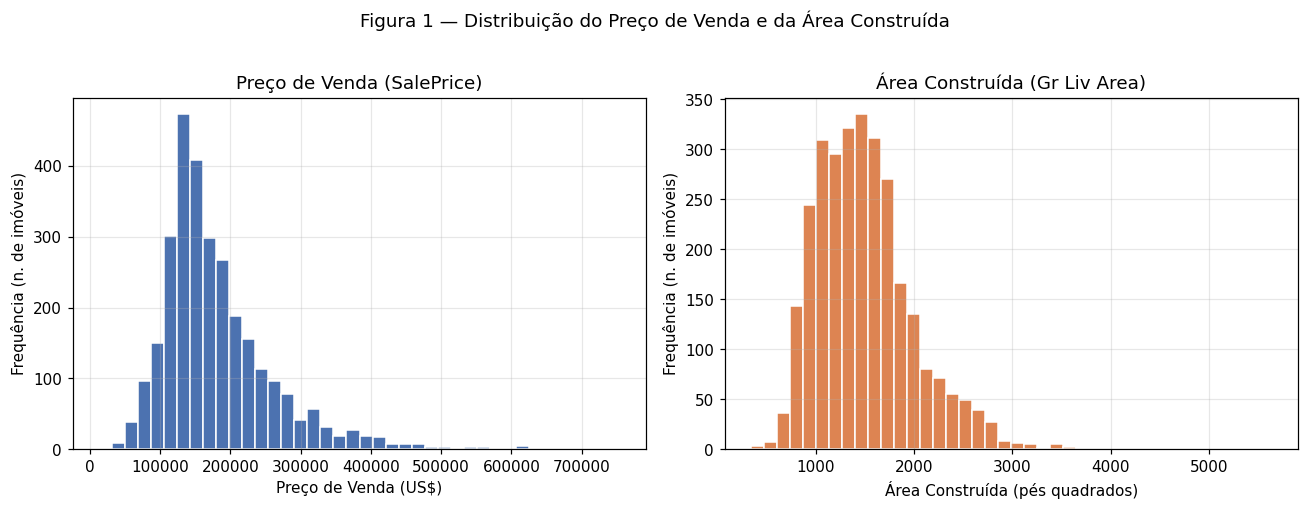

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_work['SalePrice'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Preço de Venda (SalePrice)')
axes[0].set_xlabel('Preço de Venda (US$)')
axes[0].set_ylabel('Frequência (n. de imóveis)')

axes[1].hist(df_work['Gr Liv Area'], bins=40, color='#DD8452', edgecolor='white')
axes[1].set_title('Área Construída (Gr Liv Area)')
axes[1].set_xlabel('Área Construída (pés quadrados)')
axes[1].set_ylabel('Frequência (n. de imóveis)')

fig.suptitle('Figura 1 — Distribuição do Preço de Venda e da Área Construída', y=1.02)
fig.tight_layout()
plt.show()


**Leitura:** as duas distribuições são assimétricas à direita (assimetria positiva —
confirmado pelos coeficientes de assimetria na Tabela 2), com a maior parte dos imóveis
concentrada em preços/áreas moderados e uma cauda longa de imóveis de maior valor/área.

### 3.3 Característica qualitativa B — Formato do Terreno (Lot Shape) — Tabela 3


In [ ]:
ordem_bruta_lotshape = ['Reg', 'IR1', 'IR2', 'IR3']
freq_abs = df_work['Lot Shape'].value_counts().reindex(ordem_bruta_lotshape)
freq_rel = (df_work['Lot Shape'].value_counts(normalize=True).reindex(ordem_bruta_lotshape) * 100).round(2)

tabela3 = pd.DataFrame({
    'Frequência absoluta': freq_abs,
    'Frequência relativa (%)': freq_rel,
})
tabela3.index.name = 'Formato do Terreno (Lot Shape)'
tabela3


,Frequência absoluta,Frequência relativa (%)
Formato do Terreno (Lot Shape),,
Reg,1859,63.45
IR1,979,33.41
IR2,76,2.59
IR3,16,0.55


### 3.4 Figura 2 — Gráfico de barras

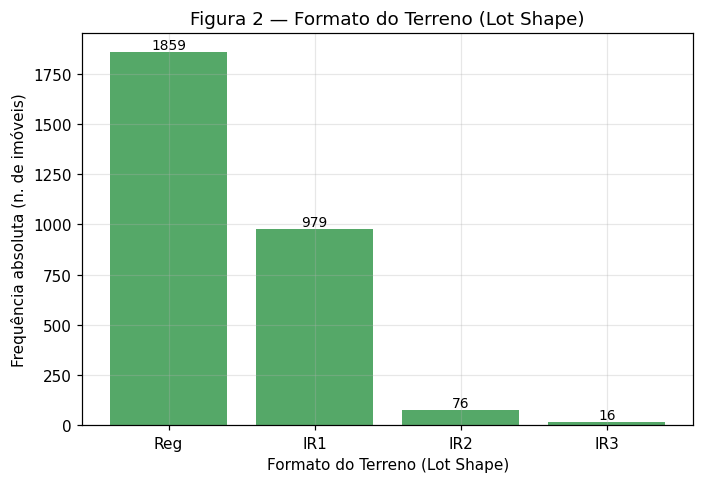

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(tabela3.index.astype(str), tabela3['Frequência absoluta'], color='#55A868')
ax.set_xlabel('Formato do Terreno (Lot Shape)')
ax.set_ylabel('Frequência absoluta (n. de imóveis)')
ax.set_title('Figura 2 — Formato do Terreno (Lot Shape)')
for i, v in enumerate(tabela3['Frequência absoluta']):
    ax.text(i, v + 15, str(v), ha='center', fontsize=9)
fig.tight_layout()
plt.show()


**Leitura preliminar:** `Reg` (formato regular) é a categoria mais comum (1859 imóveis,
63,4%), seguida por `IR1` (levemente irregular, 979 imóveis, 33,4%). As categorias `IR2`
(moderadamente irregular, 76 imóveis, 2,6%) e `IR3` (irregular, 16 imóveis, 0,5%) são raras
— esse ponto é retomado e formalizado na Seção 5, antes da análise bivariada de preço por
categoria.


## 4. Valores discrepantes — Cercas de Tukey

Aplicação obrigatória das cercas de Tukey às variáveis quantitativas selecionadas
(Preço de Venda e Área Construída):

$$LI = Q_1 - 1{,}5 \times IQR \qquad LS = Q_3 + 1{,}5 \times IQR \qquad IQR = Q_3 - Q_1$$

### Tabela 4 — Cercas de Tukey


In [ ]:
def cercas_tukey(s: pd.Series) -> dict:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_sinalizados = ((s < li) | (s > ls)).sum()
    return {'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Limite Inferior (LI)': li,
            'Limite Superior (LS)': ls, 'Casos sinalizados (n)': n_sinalizados,
            'Casos sinalizados (%)': round(n_sinalizados / len(s) * 100, 2)}

tabela4 = pd.DataFrame({
    'Preço de Venda (SalePrice)': cercas_tukey(df_work['SalePrice']),
    'Área Construída (Gr Liv Area)': cercas_tukey(df_work['Gr Liv Area']),
}).T.round(2)
tabela4


,Q1,Q3,IQR,Limite Inferior (LI),Limite Superior (LS),Casos sinalizados (n),Casos sinalizados (%)
Preço de Venda (SalePrice),129500.0,213500.00,84000.00,3500.00,339500.00,137.0,4.68
Área Construída (Gr Liv Area),1126.0,1742.75,616.75,200.88,2667.88,75.0,2.56


### Figura 3 — Boxplots (dois painéis)

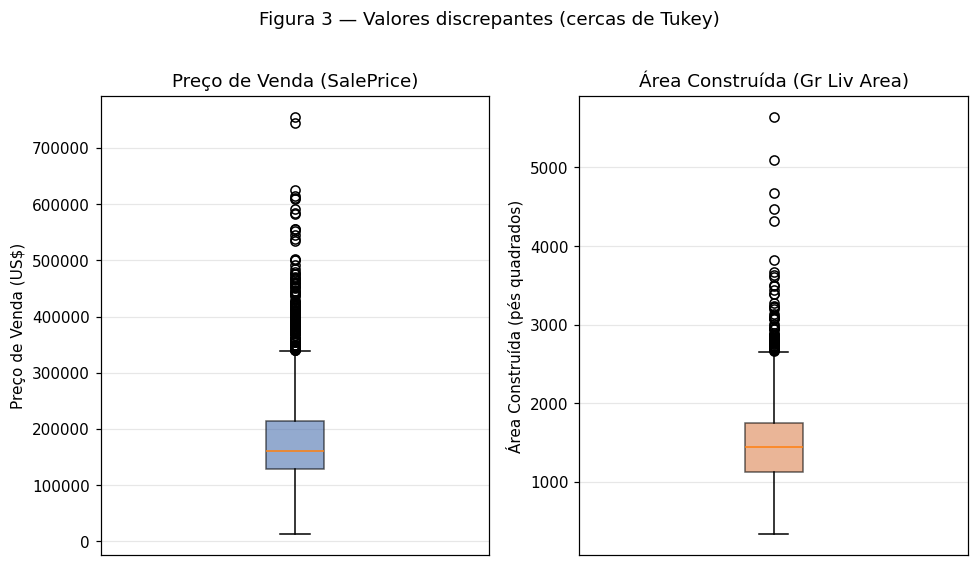

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

axes[0].boxplot(df_work['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Preço de Venda (SalePrice)')
axes[0].set_ylabel('Preço de Venda (US$)')
axes[0].set_xticks([])

axes[1].boxplot(df_work['Gr Liv Area'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#DD8452', alpha=0.6))
axes[1].set_title('Área Construída (Gr Liv Area)')
axes[1].set_ylabel('Área Construída (pés quadrados)')
axes[1].set_xticks([])

fig.suptitle('Figura 3 — Valores discrepantes (cercas de Tukey)', y=1.02)
fig.tight_layout()
plt.show()


### Investigação dos casos sinalizados

O Preço de Venda tem 137 casos acima do limite superior e a Área Construída tem 75
(nenhum caso abaixo do limite inferior em nenhuma das duas variáveis). Entre os casos de
área, destacam-se **cinco imóveis com área acima de 4000 pés²**, muito distantes do restante
da distribuição:

In [ ]:
extremos = df_work[df_work['Gr Liv Area'] > 4000][
    ['Order', 'PID', 'Gr Liv Area', 'SalePrice', 'Sale Condition', 'Yr Sold']
].sort_values('Gr Liv Area', ascending=False)
extremos


,Order,PID,Gr Liv Area,SalePrice,Sale Condition,Yr Sold
1498,1499,908154235,5642,160000,Partial,2008
2180,2181,908154195,5095,183850,Partial,2007
2181,2182,908154205,4676,184750,Partial,2007
1760,1761,528320050,4476,745000,Abnorml,2007
1767,1768,528351010,4316,755000,Normal,2007


**Decisão do grupo (mantida/corrigir/excluir), com justificativa contextual:**

**Decisão: excluir todos os imóveis que ficam fora das cercas de Tukey** em Preço de Venda
**ou** em Área Construída (união dos dois critérios). A regra é aplicada em **passo único**,
usando as cercas da Tabela 4 (calculadas sobre a base completa). Nenhum valor é corrigido ou
alterado: os casos são apenas retirados da base de trabalho.

**Justificativa:**

- **Critério objetivo e reprodutível.** A mesma regra vale para todos os casos, sem decisões
  caso a caso. Todos os casos sinalizados estão acima do limite superior (nenhum abaixo do
  limite inferior), ou seja, são imóveis de maior preço e/ou maior porte.
- **Contexto dos casos.** Há dois tipos de caso entre os excluídos. Os três imóveis com
  `Sale Condition = "Partial"` e área acima de 4000 pés² (área entre 4676 e 5642 pés² e preços
  entre US$ 160.000 e US$ 184.750) são vendas de imóvel novo ainda incompleto no momento da
  negociação — uma condição atípica que rompe a relação esperada entre área e preço. As vendas
  `Partial` aparecem de forma desproporcional entre os excluídos (61 dos 173, contra 245 dos
  2930 imóveis da base completa; Tabela 4A). Já a maioria dos demais casos são imóveis de alto
  padrão **plausíveis** para o mercado, e não erros de registro.
- **Limitação assumida.** Excluir também os imóveis de alto padrão é uma escolha
  metodológica: a base tratada passa a representar o **mercado típico** (preços até
  US$ 339.500 e áreas até 2667,88 pés²), e os resultados dela **não se estendem** aos imóveis
  de alto padrão. Por isso, a análise da Seção 6.2 é apresentada **antes e depois** da
  exclusão.
- **Efeito nas seções seguintes.** A Seção 3 (univariada) foi feita antes desta decisão e usa
  a base completa. As Seções 5, 6.1, 6.3 e 7 usam a base tratada. A Seção 6.2 usa as duas.

**Tabela 4A — Composição das exclusões**

In [ ]:
from IPython.display import display

def limites_tukey(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Cercas calculadas UMA vez, sobre a base completa (mesmos limites da Tabela 4, sem arredondamento)
li_preco, ls_preco = limites_tukey(df_work['SalePrice'])
li_area, ls_area = limites_tukey(df_work['Gr Liv Area'])

fora_preco = (df_work['SalePrice'] < li_preco) | (df_work['SalePrice'] > ls_preco)
fora_area = (df_work['Gr Liv Area'] < li_area) | (df_work['Gr Liv Area'] > ls_area)
fora_tukey = fora_preco | fora_area   # excluído se estiver fora das cercas em QUALQUER das duas variáveis

# checagem de consistência com a Tabela 4
assert fora_preco.sum() == tabela4.loc['Preço de Venda (SalePrice)', 'Casos sinalizados (n)']
assert fora_area.sum() == tabela4.loc['Área Construída (Gr Liv Area)', 'Casos sinalizados (n)']

tabela4a = pd.DataFrame({'Imóveis (n)': {
    'Fora das cercas apenas em Preço de Venda': (fora_preco & ~fora_area).sum(),
    'Fora das cercas apenas em Área Construída': (~fora_preco & fora_area).sum(),
    'Fora das cercas nas duas variáveis': (fora_preco & fora_area).sum(),
    'Total excluído (união)': fora_tukey.sum(),
    'Mantidos na base tratada': (~fora_tukey).sum(),
}})
tabela4a['% da base completa'] = (tabela4a['Imóveis (n)'] / len(df_work) * 100).round(2)
display(tabela4a)

# Contexto: condição de venda dos imóveis excluídos
cond = pd.DataFrame({
    'Excluídos (n)': df_work.loc[fora_tukey, 'Sale Condition'].value_counts(),
    'Base completa (n)': df_work['Sale Condition'].value_counts(),
}).fillna(0).astype(int)
cond['% da categoria excluída'] = (cond['Excluídos (n)'] / cond['Base completa (n)'] * 100).round(1)
cond.index.name = 'Condição de venda (Sale Condition)'
display(cond.sort_values('Base completa (n)', ascending=False))

,Imóveis (n),% da base completa
Fora das cercas apenas em Preço de Venda,98,3.34
Fora das cercas apenas em Área Construída,36,1.23
Fora das cercas nas duas variáveis,39,1.33
Total excluído (união),173,5.90
Mantidos na base tratada,2757,94.10


,Excluídos (n),Base completa (n),% da categoria excluída
Condição de venda (Sale Condition),,,
Normal,101,2413,4.2
Partial,61,245,24.9
Abnorml,7,190,3.7
Family,3,46,6.5
Alloca,1,24,4.2
AdjLand,0,12,0.0


**Tabela 4B — Comparação entre manter e excluir os casos fora das cercas**

In [ ]:
df_sem_exclusao = df_work.copy()
df_com_exclusao = df_work[~fora_tukey].copy()

def resumo_base(d: pd.DataFrame) -> dict:
    r_, _ = stats.pearsonr(d['SalePrice'], d['Gr Liv Area'])
    return {
        'Correlação de Pearson (SalePrice x Gr Liv Area)': round(r_, 4),
        'Mediana Preço de Venda (US$)': d['SalePrice'].median(),
        'Mediana Área Construída (pés²)': d['Gr Liv Area'].median(),
        'Máximo Preço de Venda (US$)': d['SalePrice'].max(),
        'Máximo Área Construída (pés²)': d['Gr Liv Area'].max(),
        # cercas recalculadas sobre cada base (informativo — a exclusão foi feita em passo único)
        'Casos fora das cercas recalculadas — Preço': cercas_tukey(d['SalePrice'])['Casos sinalizados (n)'],
        'Casos fora das cercas recalculadas — Área': cercas_tukey(d['Gr Liv Area'])['Casos sinalizados (n)'],
    }

comparacao = pd.DataFrame({
    f'Sem exclusão (n={len(df_sem_exclusao)})': resumo_base(df_sem_exclusao),
    f'Com exclusão (n={len(df_com_exclusao)})': resumo_base(df_com_exclusao),
}).T.convert_dtypes()
comparacao

,Correlação de Pearson (SalePrice x Gr Liv Area),Mediana Preço de Venda (US$),Mediana Área Construída (pés²),Máximo Preço de Venda (US$),Máximo Área Construída (pés²),Casos fora das cercas recalculadas — Preço,Casos fora das cercas recalculadas — Área
Sem exclusão (n=2930),0.7068,160000,1442,755000,5642,137,75
Com exclusão (n=2757),0.666,156500,1409,338931,2654,74,21


**Leitura:** a exclusão retira 173 imóveis (5,9% da base) e **reduz** a correlação linear
entre Preço de Venda e Área Construída (de 0,7068 para 0,6660). As medianas mudam pouco (o
corte é feito nas caudas), enquanto os máximos caem para dentro das cercas — por construção.

As duas últimas colunas da Tabela 4B mostram que, se as cercas fossem **recalculadas** sobre a base tratada, ainda
apareceriam novos casos sinalizados. Isso é esperado: ao remover a cauda, os quartis e o IQR
encolhem e as cercas se aproximam. Por isso a exclusão é feita **uma única vez**, com as cercas
da Tabela 4, e não de forma iterativa (que retiraria dados indefinidamente). A explicação de
*por que* o coeficiente muda, com os diagramas de dispersão antes e depois, está na
Seção 6.2. A partir daqui, `df_work` é atualizado para refletir essa decisão.

In [ ]:
df_work = df_com_exclusao.reset_index(drop=True)
print(f"df_work atualizado (pós-decisão de exclusão): {df_work.shape}")
print(f"Imóveis excluídos: {len(df_sem_exclusao) - len(df_work)} de {len(df_sem_exclusao)}")

df_work atualizado (pós-decisão de exclusão): (2757, 82)
Imóveis excluídos: 173 de 2930


## 5. Característica qualitativa B — Formato do Terreno (Lot Shape)

**Significado:** `Lot Shape` classifica o formato geométrico geral do lote do imóvel,
segundo quatro categorias documentadas: `Reg` (regular), `IR1` (levemente irregular), `IR2`
(moderadamente irregular) e `IR3` (irregular). É uma variável qualitativa nominal, ordenada
aqui do formato mais regular ao mais irregular por conveniência de leitura.

**Nome legível (nome original):** Formato do Terreno (`Lot Shape`).

**Frequências e categorias raras** (retomando a Tabela 3, Seção 3.3): `Reg` = 1859 imóveis
(63,4%); `IR1` = 979 imóveis (33,4%); `IR2` = 76 (2,6%); `IR3` = 16 (0,5%). Não há valores
ausentes em `Lot Shape`.

**Justificativa do agrupamento:** as categorias `IR2` e `IR3` têm, respectivamente, apenas
76 e 16 observações — números pequenos para comparações estatísticas robustas (ex.: quartis
de preço) de forma isolada, especialmente `IR3`. Por isso, `IR2` e `IR3` são agrupadas em
uma única categoria **"Irregular"**, preservando o significado (terrenos com formato
notavelmente não regular) e garantindo um tamanho amostral mais adequado (92 imóveis na base completa, 3,1%)
para comparação com as demais categorias. `Reg` e `IR1` são mantidas separadas, pois ambas
têm tamanho amostral amplo.

**Rótulos finais das categorias de B:** `Regular` (`Reg`), `Levemente Irregular` (`IR1`),
`Irregular` (`IR2` ou `IR3`). Esta decisão é registrada aqui e preservada para a AP3.

**Base utilizada nesta seção:** a coluna `B` é criada sobre `df_work` **já tratado** (Seção 4,
sem os casos fora das cercas de Tukey). As frequências finais são, portanto, ligeiramente
menores que as da Tabela 3: `Regular` = 1790, `Levemente Irregular` = 887 e `Irregular` = 80
(n = 2757), como mostra a saída abaixo.

In [ ]:
def rotular_B(codigo):
    if codigo == 'Reg':
        return 'Regular'
    elif codigo == 'IR1':
        return 'Levemente Irregular'
    else:
        return 'Irregular'

ordem_categorias_B = ['Regular', 'Levemente Irregular', 'Irregular']
df_work['B'] = pd.Categorical(df_work['Lot Shape'].apply(rotular_B),
                               categories=ordem_categorias_B, ordered=True)

print("Frequências finais da característica B (Formato do Terreno, agrupada):")
print(df_work['B'].value_counts().reindex(ordem_categorias_B))


Frequências finais da característica B (Formato do Terreno, agrupada):
B
Regular                1790
Levemente Irregular     887
Irregular                80
Name: count, dtype: int64


## 6. Análise bivariada

**Base utilizada:** as análises 6.1 e 6.3 usam a **base tratada** (Seção 4, n = 2757). A
análise 6.2 apresenta a base completa **e** a base tratada, lado a lado.

### 6.1 Preço de Venda (SalePrice) x Ano da Venda (Yr Sold) — Tabela 5

In [ ]:
tabela5 = df_work.groupby('Yr Sold').agg(
    Quantidade_de_vendas=('SalePrice', 'count'),
    Mediana_do_Preco=('SalePrice', 'median'),
).rename(columns={'Quantidade_de_vendas': 'Quantidade de Vendas',
                   'Mediana_do_Preco': 'Mediana do Preço de Venda (US$)'})
tabela5.index.name = 'Ano da Venda (Yr Sold)'
tabela5


,Quantidade de Vendas,Mediana do Preço de Venda (US$)
Ano da Venda (Yr Sold),,
2006,587,156500.0
2007,648,158225.0
2008,581,155000.0
2009,612,157250.0
2010,329,154000.0


### Figura 4 — Mediana anual do Preço de Venda

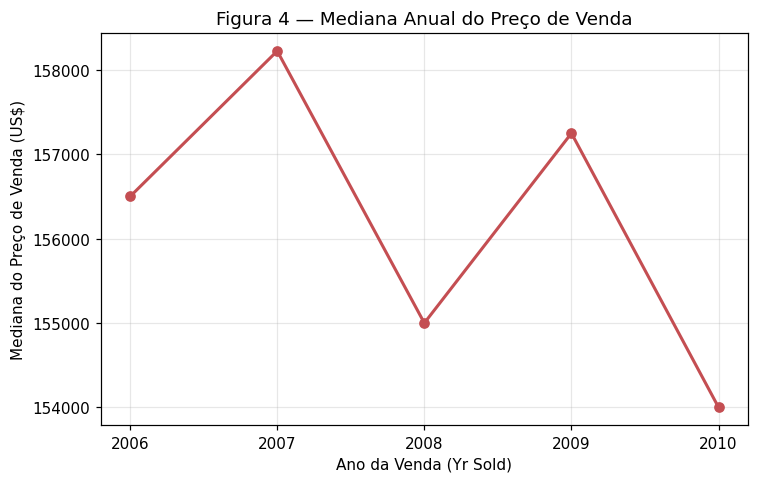

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tabela5.index, tabela5['Mediana do Preço de Venda (US$)'],
        marker='o', color='#C44E52', linewidth=2)
ax.set_xlabel('Ano da Venda (Yr Sold)')
ax.set_ylabel('Mediana do Preço de Venda (US$)')
ax.set_title('Figura 4 — Mediana Anual do Preço de Venda')
ax.set_xticks(tabela5.index)
fig.tight_layout()
plt.show()


**Discussão:** a linha conecta **medianas anuais agregadas**, não preços de imóveis
individuais — nenhum imóvel é acompanhado ao longo do tempo. As diferenças observadas entre
anos podem refletir a **composição dos imóveis vendidos em cada ano** (mix de tamanhos,
localizações e padrões), efeitos de **inflação** e **condições gerais do mercado** (2008–2009
coincide com a crise financeira internacional) — não uma tendência causal, nem uma análise
formal de série temporal. O Mês da Venda (`Mo Sold`) poderia servir como extensão descritiva
(sazonalidade dentro do ano), mas não substitui a agregação anual acima, que é a exigida.

### 6.2 Preço de Venda (SalePrice) x Área Construída (Gr Liv Area)

Esta seção analisa a relação entre as duas variáveis em **dois cenários**, para mostrar como
os valores discrepantes afetam o diagrama de dispersão e o coeficiente de correlação:

- **Antes da exclusão:** base completa (n = 2930).
- **Depois da exclusão:** base tratada, sem os 173 imóveis fora das cercas de Tukey (Seção 4)
  (n = 2757).

**Figura 5 — Diagramas de dispersão antes (5a) e depois (5b) da exclusão**

Os dois painéis usam **os mesmos eixos**, para que sejam diretamente comparáveis. Em 5a, os
pontos em vermelho são os que saem na exclusão e as linhas tracejadas são as cercas
superiores de Tukey (Tabela 4).

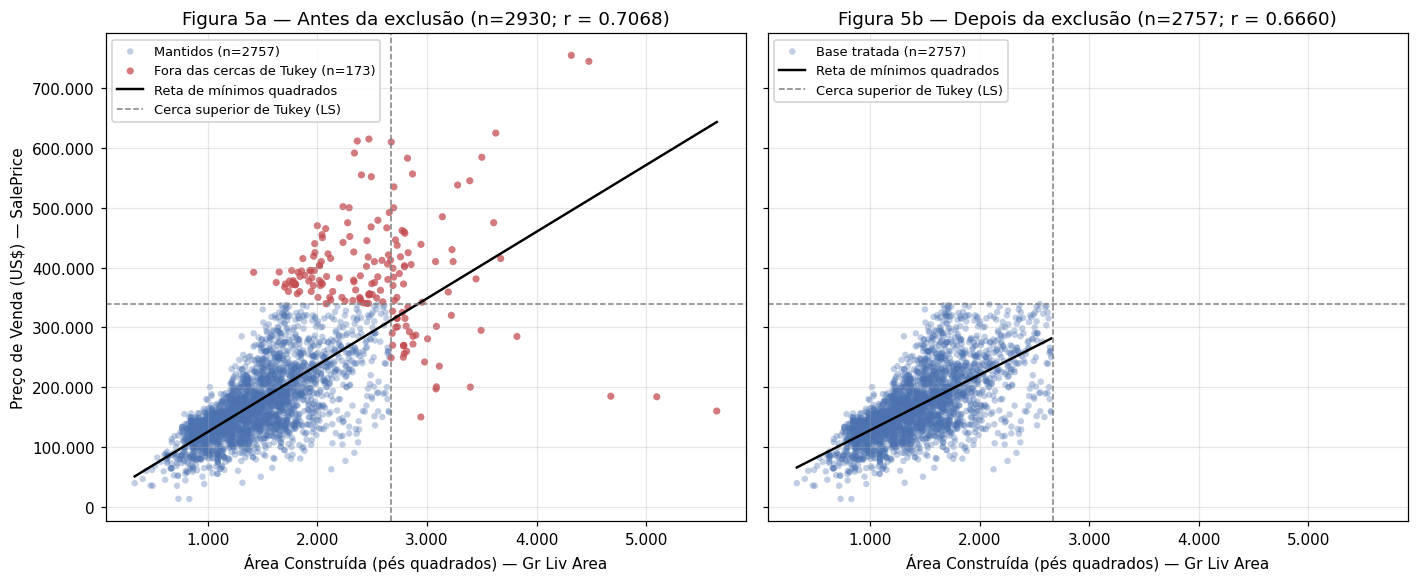

In [ ]:
from matplotlib.ticker import FuncFormatter

fmt_milhar = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

def reta_mq(d):
    b, a = np.polyfit(d['Gr Liv Area'], d['SalePrice'], 1)
    return a, b

r_antes, _ = stats.pearsonr(df_sem_exclusao['Gr Liv Area'], df_sem_exclusao['SalePrice'])
r_depois, _ = stats.pearsonr(df_work['Gr Liv Area'], df_work['SalePrice'])

def xs_de(d):
    return np.linspace(d['Gr Liv Area'].min(), d['Gr Liv Area'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharex=True, sharey=True)

# (a) ANTES — base completa, com os casos excluídos destacados
ax = axes[0]
mantidos = df_sem_exclusao[~fora_tukey]
excluidos = df_sem_exclusao[fora_tukey]
ax.scatter(mantidos['Gr Liv Area'], mantidos['SalePrice'], alpha=0.35, s=18,
           color='#4C72B0', edgecolor='none', label=f'Mantidos (n={len(mantidos)})')
ax.scatter(excluidos['Gr Liv Area'], excluidos['SalePrice'], alpha=0.75, s=22,
           color='#C44E52', edgecolor='none', label=f'Fora das cercas de Tukey (n={len(excluidos)})')
a_, b_ = reta_mq(df_sem_exclusao)
ax.plot(xs_de(df_sem_exclusao), a_ + b_ * xs_de(df_sem_exclusao), color='black', lw=1.6,
        label='Reta de mínimos quadrados')
ax.axvline(ls_area, color='gray', ls='--', lw=1, label='Cerca superior de Tukey (LS)')
ax.axhline(ls_preco, color='gray', ls='--', lw=1)
ax.set_title(f'Figura 5a — Antes da exclusão (n={len(df_sem_exclusao)}; r = {r_antes:.4f})')
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

# (b) DEPOIS — base tratada
ax = axes[1]
ax.scatter(df_work['Gr Liv Area'], df_work['SalePrice'], alpha=0.35, s=18,
           color='#4C72B0', edgecolor='none', label=f'Base tratada (n={len(df_work)})')
a_, b_ = reta_mq(df_work)
ax.plot(xs_de(df_work), a_ + b_ * xs_de(df_work), color='black', lw=1.6,
        label='Reta de mínimos quadrados')
ax.axvline(ls_area, color='gray', ls='--', lw=1, label='Cerca superior de Tukey (LS)')
ax.axhline(ls_preco, color='gray', ls='--', lw=1)
ax.set_title(f'Figura 5b — Depois da exclusão (n={len(df_work)}; r = {r_depois:.4f})')
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

for ax in axes:
    ax.set_xlabel('Área Construída (pés quadrados) — Gr Liv Area')
    ax.xaxis.set_major_formatter(fmt_milhar)
    ax.yaxis.set_major_formatter(fmt_milhar)
axes[0].set_ylabel('Preço de Venda (US$) — SalePrice')

fig.tight_layout()
plt.show()

**Tabela 5A — Correlação linear de Pearson antes e depois da exclusão**

In [ ]:
def pearson_resumo(d: pd.DataFrame) -> dict:
    r_, p_ = stats.pearsonr(d['Gr Liv Area'], d['SalePrice'])
    b_, _ = np.polyfit(d['Gr Liv Area'], d['SalePrice'], 1)
    return {
        'n': len(d),
        'r de Pearson': round(r_, 4),
        'r² (coef. de determinação)': round(r_ ** 2, 4),
        'p-valor': f"{p_:.2e}",
        'Inclinação da reta (US$ por pé²)': round(b_, 2),
        'DP da Área Construída (pés²)': round(d['Gr Liv Area'].std(), 1),
        'DP do Preço de Venda (US$)': round(d['SalePrice'].std(), 0),
    }

res_antes = pearson_resumo(df_sem_exclusao)
res_depois = pearson_resumo(df_work)

tabela5a = pd.DataFrame({
    'Antes da exclusão (base completa)': res_antes,
    'Depois da exclusão (base tratada)': res_depois,
}).T

# linha de variação (depois − antes) para as colunas numéricas
variacao = {k: (round(res_depois[k] - res_antes[k], 4) if k != 'p-valor' else '—') for k in res_antes}
tabela5a.loc['Variação (depois − antes)'] = pd.Series(variacao)
tabela5a

,n,r de Pearson,r² (coef. de determinação),p-valor,Inclinação da reta (US$ por pé²),DP da Área Construída (pés²),DP do Preço de Venda (US$)
Antes da exclusão (base completa),2930,0.7068,0.4995,0.00e+00,111.69,505.5,79887.0
Depois da exclusão (base tratada),2757,0.666,0.4436,0.00e+00,92.99,415.7,58047.0
Variação (depois − antes),-173,-0.0408,-0.0559,—,-18.7,-89.8,-21840.0


**Tabela 5B — Sensibilidade: de onde vem a mudança em r?**

Para entender *por que* o coeficiente muda, a Tabela 5B refaz o cálculo retirando os casos
em grupos separados (todos com as mesmas cercas da Tabela 4).

In [ ]:
cenarios = {
    'Base completa': pd.Series(False, index=df_sem_exclusao.index),
    'Sem os 5 imóveis com área > 4000 pés² (critério anterior)': df_sem_exclusao['Gr Liv Area'] > 4000,
    'Sem os outliers de Área Construída (Tukey)': fora_area,
    'Sem os outliers de Preço de Venda (Tukey)': fora_preco,
    'Sem todos os outliers de Tukey (adotado)': fora_tukey,
}

linhas = {}
for nome, excluir in cenarios.items():
    d = df_sem_exclusao[~excluir]
    r_, _ = stats.pearsonr(d['Gr Liv Area'], d['SalePrice'])
    b_, _ = np.polyfit(d['Gr Liv Area'], d['SalePrice'], 1)
    linhas[nome] = {
        'Excluídos (n)': int(excluir.sum()),
        'Restantes (n)': len(d),
        'r de Pearson': round(r_, 4),
        'r²': round(r_ ** 2, 4),
        'Inclinação (US$ por pé²)': round(b_, 2),
    }

tabela5b = pd.DataFrame(linhas).T.convert_dtypes()
tabela5b

,Excluídos (n),Restantes (n),r de Pearson,r²,Inclinação (US$ por pé²)
Base completa,0,2930,0.7068,0.4995,111.69
Sem os 5 imóveis com área > 4000 pés² (critério anterior),5,2925,0.7195,0.5176,116.23
Sem os outliers de Área Construída (Tukey),75,2855,0.6835,0.4671,113.54
Sem os outliers de Preço de Venda (Tukey),137,2793,0.6523,0.4254,83.59
Sem todos os outliers de Tukey (adotado),173,2757,0.666,0.4436,92.99


### Interpretação — Preço de Venda x Área Construída

**Direção, forma, grupos e valores discrepantes (diagrama de dispersão).**

*Antes da exclusão (Figura 5a).* A **direção** é positiva: áreas maiores acompanham preços
maiores. A **forma** é aproximadamente linear, com **espalhamento vertical crescente** em
áreas maiores (formato de leque): para áreas pequenas os preços ficam concentrados perto da
reta, e para áreas grandes variam muito mais. Não há **grupos** claramente separados: os
pontos formam uma única nuvem densa, concentrada entre cerca de 800 e 2.000 pés² e
US 100.000 a US 250.000. Os **valores discrepantes** são de três tipos: (i) imóveis acima da
cerca de preço (US 339.500), com área de moderada a grande, bem **acima** da reta;
(ii) imóveis acima da cerca de área (2667,88 pés²) com preço dentro da cerca, que ficam em
geral **abaixo** da reta (preço menor do que o esperado para o tamanho); e (iii) os cinco
imóveis com mais de 4000 pés², isolados à direita: três vendas `Partial` muito abaixo da reta
e dois imóveis de US 745.000 e US 755.000, acima dela.

*Depois da exclusão (Figura 5b).* Direção e forma se mantêm: relação positiva, aproximadamente
linear, ainda em leque, porém mais estreito. A nuvem fica **cortada de forma abrupta** nas
cercas (topo e lado direito), a reta fica mais plana e não restam pontos isolados do restante
da nuvem.

**Intensidade e direção (correlação de Pearson).** Antes da exclusão, r = 0,7068 (r² ≈ 0,50):
associação linear **positiva** e **forte**. Depois da exclusão, r = 0,6660 (r² ≈ 0,44):
continua **positiva**, mas passa a **moderada a forte** (classificação convencional; os
limites entre "moderada" e "forte" variam entre autores). Em termos de r², cerca de 50% da
variação do preço está associada linearmente à variação da área na base completa, e cerca de
44% na base tratada. O p-valor é praticamente zero nos dois casos: com milhares de
observações, a correlação é distinguível de zero, mas isso não mede a intensidade da
associação. O coeficiente descreve **associação linear**, **não causalidade**: imóveis maiores
tendem a ser vendidos por preços maiores, mas r não diz que a área *causa* o preço. Qualidade
construtiva, bairro e idade do imóvel, por exemplo, também se associam às duas variáveis e não
aparecem neste gráfico bivariado.

**O que mudou e por quê.** O coeficiente **caiu** (−0,0408) e a reta ficou mais plana (de
US 111,69 para US 92,99 por pé²). A Tabela 5B mostra que a exclusão mistura dois efeitos
de sentidos contrários:

1. **Os 5 imóveis com área acima de 4000 pés² atrapalhavam o ajuste linear.** Retirar apenas
   esses cinco **eleva** r (0,7068 → 0,7195). Três deles são vendas `Partial` com área enorme
   e preço baixo (US 160.000 a US 184.750): ficam muito abaixo da tendência e, por terem
   valores extremos de área (alta alavancagem), puxam o coeficiente para baixo. Esse é o caso
   clássico em que um valor discrepante **enfraquece** r.
2. **Os demais imóveis excluídos são caros e/ou grandes, não erros de registro.** Retirá-los
   **restringe a amplitude** dos dados: o desvio-padrão do preço cai de ≈ US 79.900 para
   ≈ US 58.000, e o da área, de ≈ 505 para ≈ 416 pés² (Tabela 5A). O r compara a variação
   conjunta das variáveis com a variação total de cada uma; ao cortar as caudas, retira-se
   parte da variação que seguia a tendência e o ruído em torno da reta passa a pesar mais.
   O efeito é maior ao cortar por **preço** (r = 0,6523; inclinação cai para US 83,59 por
   pé²) do que por **área** (r = 0,6835; inclinação praticamente igual à original): cortar pela
   própria variável de preço elimina também imóveis de área moderada e preço alto, e isso
   achata a reta e atenua a correlação. Ao somar a exclusão por área, r sobe um pouco
   (0,6523 → 0,6660), pois esses imóveis grandes ficam, em geral, abaixo da reta.

**Como valores discrepantes afetam o coeficiente.** O r de Pearson é calculado com médias e
desvios-padrão, por isso é **sensível** a valores extremos, e o sentido do efeito depende de
*onde* o ponto está: um ponto extremo **fora** da tendência (como as vendas `Partial`) tende a
**diminuir** r; um ponto extremo **sobre** a tendência tende a **aumentá-lo**; e retirar
pontos de cauda que seguem a tendência, como feito aqui, **diminui** r por restrição de
amplitude. Na prática, as duas versões devem ser lidas juntas: r = 0,7068 descreve o mercado
completo, incluindo imóveis de alto padrão, e r = 0,6660 descreve o mercado típico (preços até
US 339.500 e áreas até 2667,88 pés²). A diferença entre elas **não indica erro nos dados**,
e sim o efeito de restringir a amostra.

In [ ]:
def resumo_preco_por_grupo(s: pd.Series) -> dict:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return {'n': s.count(), 'Mediana': s.median(), 'Q1': q1, 'Q3': q3, 'IQR': q3 - q1}

tabela6 = df_work.groupby('B', observed=True)['SalePrice'].apply(
    lambda s: pd.Series(resumo_preco_por_grupo(s))
).unstack().reindex(ordem_categorias_B).round(2)
tabela6


,n,Mediana,Q1,Q3,IQR
B,,,,,
Regular,1790.0,143000.0,119900.0,179150.0,59250.0
Levemente Irregular,887.0,185000.0,149950.0,226875.0,76925.0
Irregular,80.0,201500.0,172250.0,240000.0,67750.0


**Figura 6 — Boxplots do preço por categoria de B**

/tmp/ipykernel_127/2538898336.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_grupos, labels=ordem_categorias_B, patch_artist=True)


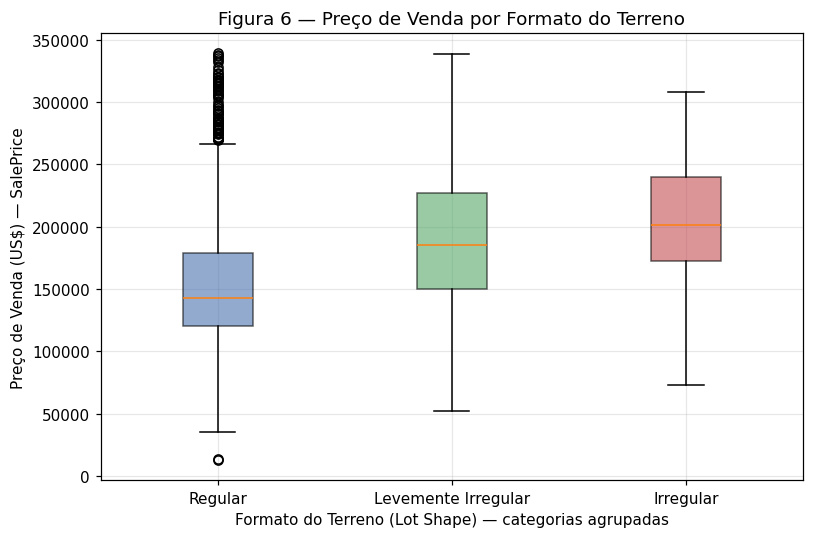

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))
dados_grupos = [df_work.loc[df_work['B'] == cat, 'SalePrice'] for cat in ordem_categorias_B]
bp = ax.boxplot(dados_grupos, labels=ordem_categorias_B, patch_artist=True)
for patch, cor in zip(bp['boxes'], ['#4C72B0', '#55A868', '#C44E52']):
    patch.set_facecolor(cor)
    patch.set_alpha(0.6)
ax.set_xlabel('Formato do Terreno (Lot Shape) — categorias agrupadas')
ax.set_ylabel('Preço de Venda (US$) — SalePrice')
ax.set_title('Figura 6 — Preço de Venda por Formato do Terreno')
fig.tight_layout()
plt.show()


**Interpretação:** a mediana do Preço de Venda é **mais baixa** no grupo "Regular" e
**mais alta** nos grupos "Levemente Irregular" e "Irregular" — contraintuitivo à primeira
vista, mas plausível: lotes irregulares muitas vezes aparecem em bairros mais antigos e
valorizados, ou em terrenos maiores/de esquina, o que pode elevar o preço por razões alheias
ao formato em si. A dispersão (IQR) também varia entre os grupos, com mais valores
discrepantes de preço no grupo "Regular" (o mais numeroso). Essas diferenças são
**descritivas**: não foi realizado nenhum teste de hipótese, e não se atribui causalidade ao
formato do terreno — outras características do imóvel e da localização, não capturadas
aqui, provavelmente explicam boa parte da diferença observada.

*Nota:* a Tabela 6 e a Figura 6 usam a base tratada (sem os casos fora das cercas **globais**
de Tukey da Seção 4). Os boxplots por grupo usam cercas **próprias de cada grupo**, por isso
ainda podem sinalizar pontos (no grupo "Regular") mesmo após a exclusão.

## 7. Exportação do dado pré-processado

### Registro explícito — nomes originais e nomes utilizados


In [ ]:
NOMES_LEGIVEIS = {
    'PID': 'Identificador do imóvel',
    'SalePrice': 'Preço de Venda',
    'Gr Liv Area': 'Área Construída',
    'Lot Shape': 'Formato do Terreno (base categórica da característica B)',
    'B': 'Característica qualitativa B — Formato do Terreno (categorias agrupadas)',
    'Fireplaces': 'Número de Lareiras',
    'Mas Vnr Area': 'Área de Revestimento em Alvenaria',
    'Mas Vnr Type': 'Tipo de Revestimento em Alvenaria',
    'Year Built': 'Ano de Construção',
    'Year Remod/Add': 'Ano de Reforma/Adição',
    'Yr Sold': 'Ano da Venda',
    'Mo Sold': 'Mês da Venda',
}
pd.DataFrame(list(NOMES_LEGIVEIS.items()), columns=['Nome original', 'Nome legível'])


,Nome original,Nome legível
0,PID,Identificador do imóvel
1,SalePrice,Preço de Venda
2,Gr Liv Area,Área Construída
3,Lot Shape,Formato do Terreno (base categórica da caracte...
4,B,Característica qualitativa B — Formato do Terr...
5,Fireplaces,Número de Lareiras
6,Mas Vnr Area,Área de Revestimento em Alvenaria
7,Mas Vnr Type,Tipo de Revestimento em Alvenaria
8,Year Built,Ano de Construção
9,Year Remod/Add,Ano de Reforma/Adição


### Tratamentos realizados (resumo)

1. **Duplicidades:** nenhuma encontrada (0 linhas duplicadas, 0 `PID` duplicado).
2. **`Mas Vnr Area`:** os 23 valores verdadeiramente ausentes (tipo e área ausentes
   simultaneamente) foram **preservados como `NaN`** — não classificados automaticamente
   como "sem revestimento" (0). Nenhuma imputação foi aplicada nesta AP2.
3. **`Year Built` / `Year Remod/Add`:** 1 inconsistência lógica encontrada (reforma anterior
   à construção) — **documentada, sem correção automática**, pois essas colunas não são
   usadas nas análises quantitativas exigidas nesta AP2.
4. **Valores discrepantes (Tukey):** foram **excluídos todos os 173 imóveis fora das cercas de
   Tukey** em `SalePrice` ou `Gr Liv Area` (137 em preço, 75 em área, 39 nas duas), em passo
   único, com as cercas da Tabela 4. A base tratada tem 2757 imóveis. A comparação
   antes/depois está nas Seções 4 e 6.2 (diagramas de dispersão e correlação de Pearson).
5. **Característica B (`Lot Shape`):** agrupada em 3 categorias — `Regular` (`Reg`),
   `Levemente Irregular` (`IR1`), `Irregular` (`IR2` ou `IR3`) — devido à raridade das
   categorias `IR2` e `IR3` isoladamente (76 e 16 observações, respectivamente).

### Agrupamento final e rótulos de B

- **Variável:** Formato do Terreno (`Lot Shape`)
- **Categorias finais:** `Regular`, `Levemente Irregular`, `Irregular`
- **Coluna criada:** `B` (tipo categórico ordenado), preservada no arquivo exportado

### Reprodução

Para reproduzir a versão organizada: execute este notebook do início ao fim com acesso à
internet (para baixar `AmesHousing_full.txt` do repositório GitHub em
`https://raw.githubusercontent.com/artPPUNI06/Meu_Projeto/main/data/raw/AmesHousing_full.txt`)
ou com esse mesmo arquivo já presente em `data/raw/`. O notebook lê o arquivo bruto, aplica
os tratamentos documentados nas Seções 2, 4 e 5 (nesta ordem), e grava o resultado em
`data/processed/AmesHousing.csv`.

In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

OUTPUT_PATH = 'data/processed/AmesHousing.csv'
df_work.to_csv(OUTPUT_PATH, sep=',', encoding='utf-8', index=False)

print(f"Arquivo processado salvo em: {OUTPUT_PATH}")
print(f"Dimensões finais: {df_work.shape[0]} linhas x {df_work.shape[1]} colunas")
print(f"Colunas: {list(df_work.columns[-3:])} ... (inclui coluna 'B' adicionada)")


Arquivo processado salvo em: data/processed/AmesHousing.csv
Dimensões finais: 2757 linhas x 83 colunas
Colunas: ['Sale Condition', 'SalePrice', 'B'] ... (inclui coluna 'B' adicionada)


In [ ]:
# Checagem final de reprodutibilidade: recarregar o arquivo processado
df_check = pd.read_csv(OUTPUT_PATH)
print(f"Releitura de {OUTPUT_PATH}: {df_check.shape}")
df_check[['PID', 'SalePrice', 'Gr Liv Area', 'Lot Shape', 'B']].head()


Releitura de data/processed/AmesHousing.csv: (2757, 83)


,PID,SalePrice,Gr Liv Area,Lot Shape,B
0,526301100,215000,1656,IR1,Levemente Irregular
1,526350040,105000,896,Reg,Regular
2,526351010,172000,1329,IR1,Levemente Irregular
3,526353030,244000,2110,Reg,Regular
4,527105010,189900,1629,IR1,Levemente Irregular
